# Component 1: Three-Month Forecast Validation

## tl;dr

This notebook performs a true out-of-sample evaluation of the forecasts saved in May 2026. The
forecast files are kept unchanged and are joined to market prices observed after the original
May 7 data cutoff.

- **JKH:** the July 30 close was **LKR 19.80**, compared with an ensemble forecast of
  **LKR 22.53**. The endpoint overestimate was **LKR 2.73 (13.78%)**.
- **BIL:** the July 30 close was **LKR 5.20**, compared with an ensemble forecast of
  **LKR 6.87**. The endpoint overestimate was **LKR 1.67 (32.13%)**.
- The no-change baseline produced lower path error than the ensemble for both stocks.
- The 95% prediction bands covered all matched observations, but the intervals were very wide.
  This is coverage, not evidence that the point forecast was accurate.

**Research conclusion:** the three-month upward scenario did not validate during this period. The
model remains useful as an expected-price and anomaly-analysis framework, but these results do not
support a claim of reliable three-month directional forecasting.

## Context & Methods

### Research question

How closely did the three-month JKH and BIL forecasts, generated from information available through
May 7, 2026, match realized CSE closing prices from May 8 to July 30, 2026?

### Key assumptions

1. The saved forecast files are treated as **locked predictions**. They are never retrained or
   modified using later prices.
2. Evaluation uses one row per CSE trading date. Forecast dates with no corresponding market
   observation are excluded rather than filled with invented prices.
3. The main point forecast is `predicted_close`, the saved ensemble output.
4. The previous-close random walk is the main naive baseline because a research model should beat a
   simple alternative before stronger forecasting claims are made.
5. The data source is the same TradingView CSELK fallback used by the original research package.
   It should still be reconciled with official CSE data before publication.

### Metrics

- **MAE:** average absolute price error in LKR.
- **RMSE:** price error that gives additional weight to large misses.
- **MAPE:** average absolute percentage error relative to the realized close.
- **Bias:** average signed error (`forecast - actual`); positive bias means overprediction.
- **Interval coverage:** percentage of actual closes inside the saved uncertainty interval.

## Data

### 1. Load the locked forecasts and realized prices

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def find_component_directory() -> Path:
    # Locate research/component1 whether Jupyter starts in the repo or notebook folder.
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        direct = candidate / "research" / "component1"
        if direct.exists():
            return direct
        if candidate.name == "component1" and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate research/component1 from the current directory.")


COMPONENT_DIR = find_component_directory()
FORECAST_DIR = COMPONENT_DIR / "data" / "locked_forecasts"
ACTUAL_DIR = COMPONENT_DIR / "data" / "actuals"
TRAINING_DIR = COMPONENT_DIR / "data" / "training"
OUTPUT_DIR = COMPONENT_DIR / "artifacts" / "validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STOCKS = {
    "JKH": {
        "forecast": FORECAST_DIR / "JKH_forecast_created_2026-05-10.csv",
        "actual": ACTUAL_DIR / "JKH_actual_through_2026-08-28.csv",
        "training": TRAINING_DIR / "JKH_history_through_2026-05-07.csv",
    },
    "BIL": {
        "forecast": FORECAST_DIR / "BIL_forecast_created_2026-05-10.csv",
        "actual": ACTUAL_DIR / "BIL_actual_through_2026-08-28.csv",
        "training": TRAINING_DIR / "BIL_history_through_2026-05-07.csv",
    },
}

source_inventory = pd.DataFrame(
    [
        {
            "stock": stock,
            "forecast_file": paths["forecast"].name,
            "actual_file": paths["actual"].name,
            "training_cutoff_file": paths["training"].name,
        }
        for stock, paths in STOCKS.items()
    ]
)
display(source_inventory)

,stock,forecast_file,actual_file,training_cutoff_file
0,JKH,JKH_forecast_created_2026-05-10.csv,JKH_actual_through_2026-08-28.csv,JKH_history_through_2026-05-07.csv
1,BIL,BIL_forecast_created_2026-05-10.csv,BIL_actual_through_2026-08-28.csv,BIL_history_through_2026-05-07.csv


### 2. Verify data quality and historical consistency

In [2]:
def load_csv(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, parse_dates=["date"])
    return frame.sort_values("date").reset_index(drop=True)


def profile_market_data(stock: str, frame: pd.DataFrame) -> dict:
    invalid_ohlc = (
        (frame["high"] < frame[["open", "close", "low"]].max(axis=1))
        | (frame["low"] > frame[["open", "close", "high"]].min(axis=1))
        | (frame["low"] > frame["high"])
    )
    return {
        "stock": stock,
        "rows": len(frame),
        "start_date": frame["date"].min().date(),
        "end_date": frame["date"].max().date(),
        "duplicate_dates": int(frame["date"].duplicated().sum()),
        "missing_ohlcv": int(frame[["open", "high", "low", "close", "volume"]].isna().sum().sum()),
        "invalid_ohlc_rows": int(invalid_ohlc.sum()),
        "negative_volume_rows": int((frame["volume"] < 0).sum()),
        "source": ", ".join(sorted(frame["source"].dropna().unique())),
    }


quality_rows = []
reconciliation_rows = []
loaded = {}

for stock, paths in STOCKS.items():
    forecast = load_csv(paths["forecast"])
    actual = load_csv(paths["actual"])
    training = load_csv(paths["training"])
    loaded[stock] = {"forecast": forecast, "actual": actual, "training": training}

    evaluation_actual = actual[
        actual["date"].between(forecast["date"].min(), forecast["date"].max())
    ].copy()
    quality_rows.append(profile_market_data(stock, evaluation_actual))

    # Reconcile the re-downloaded history to every original row available at training time.
    overlap = actual[actual["date"] <= training["date"].max()]
    comparison = training[["date", "open", "high", "low", "close", "volume"]].merge(
        overlap[["date", "open", "high", "low", "close", "volume"]],
        on="date",
        how="outer",
        suffixes=("_training", "_redownload"),
        indicator=True,
        validate="one_to_one",
    )
    mismatch_count = 0
    for column in ["open", "high", "low", "close", "volume"]:
        both = comparison["_merge"].eq("both")
        mismatch_count += int(
            ((comparison.loc[both, f"{column}_training"] - comparison.loc[both, f"{column}_redownload"]).abs() > 1e-8).sum()
        )
    reconciliation_rows.append(
        {
            "stock": stock,
            "original_rows": len(training),
            "matched_dates": int(comparison["_merge"].eq("both").sum()),
            "missing_or_added_dates": int(comparison["_merge"].ne("both").sum()),
            "ohlcv_value_mismatches": mismatch_count,
        }
    )

quality_df = pd.DataFrame(quality_rows)
reconciliation_df = pd.DataFrame(reconciliation_rows)
display(Markdown("**Validation-window quality checks**"))
display(quality_df)
display(Markdown("**Original-vs-redownloaded history through May 7, 2026**"))
display(reconciliation_df)

**Validation-window quality checks**

,stock,rows,start_date,end_date,duplicate_dates,missing_ohlcv,invalid_ohlc_rows,negative_volume_rows,source
0,JKH,57,2026-05-08,2026-07-30,0,0,0,0,tradingview_cselk_fallback
1,BIL,57,2026-05-08,2026-07-30,0,0,0,0,tradingview_cselk_fallback


**Original-vs-redownloaded history through May 7, 2026**

,stock,original_rows,matched_dates,missing_or_added_dates,ohlcv_value_mismatches
0,JKH,3308,3308,0,0
1,BIL,3238,3238,0,0


## Results

### 3. Match forecasts to realized CSE trading dates

The saved forecast contains 60 weekday rows. The exchange has 57 observed trading dates in the
period, so three forecast-only dates are excluded from error calculations. This exact-date join avoids
silently shifting predictions to a different day.

In [3]:
MODEL_COLUMNS = {
    "Ensemble forecast": "predicted_close",
    "LSTM scenario": "scenario_lstm_close",
    "No-change baseline": "naive_random_walk_close",
    "Moving-average drift": "moving_average_drift_close",
}


def calculate_metrics(actual: pd.Series, predicted: pd.Series) -> dict:
    error = predicted - actual
    return {
        "mae_lkr": error.abs().mean(),
        "rmse_lkr": np.sqrt(np.mean(np.square(error))),
        "mape_pct": np.mean(error.abs() / actual) * 100,
        "bias_lkr": error.mean(),
    }


evaluation_frames = {}
metric_rows = []
date_alignment_rows = []

for stock, frames in loaded.items():
    forecast = frames["forecast"]
    actual = frames["actual"]
    actual_window = actual[
        actual["date"].between(forecast["date"].min(), forecast["date"].max())
    ][["date", "close", "volume"]]
    matched = forecast.merge(actual_window, on="date", how="inner", validate="one_to_one")
    evaluation_frames[stock] = matched
    matched.to_csv(OUTPUT_DIR / f"{stock}_forecast_vs_actual.csv", index=False)

    missing_dates = forecast.loc[~forecast["date"].isin(matched["date"]), "date"]
    date_alignment_rows.append(
        {
            "stock": stock,
            "forecast_rows": len(forecast),
            "actual_trading_rows": len(actual_window),
            "matched_rows": len(matched),
            "excluded_forecast_dates": ", ".join(missing_dates.dt.strftime("%Y-%m-%d")),
        }
    )

    for model_name, column in MODEL_COLUMNS.items():
        row = {"stock": stock, "model": model_name}
        row.update(calculate_metrics(matched["close"], matched[column]))
        metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)
date_alignment_df = pd.DataFrame(date_alignment_rows)
metrics_df.to_csv(OUTPUT_DIR / "forecast_validation_metrics.csv", index=False)
date_alignment_df.to_csv(OUTPUT_DIR / "forecast_date_alignment.csv", index=False)

display(date_alignment_df)
display(
    metrics_df.sort_values(["stock", "mae_lkr"])
    .style.format({"mae_lkr": "{:.4f}", "rmse_lkr": "{:.4f}", "mape_pct": "{:.2f}%", "bias_lkr": "{:+.4f}"})
)

,stock,forecast_rows,actual_trading_rows,matched_rows,excluded_forecast_dates
0,JKH,60,57,57,"2026-05-28, 2026-06-29, 2026-07-29"
1,BIL,60,57,57,"2026-05-28, 2026-06-29, 2026-07-29"


,stock,model,mae_lkr,rmse_lkr,mape_pct,bias_lkr
6,BIL,No-change baseline,0.6561,0.7276,11.76%,+0.6526
5,BIL,LSTM scenario,0.8565,0.9631,15.38%,+0.8532
4,BIL,Ensemble forecast,0.8822,0.9884,15.83%,+0.8789
7,BIL,Moving-average drift,1.1420,1.2864,20.50%,+1.1390
2,JKH,No-change baseline,0.5474,0.6170,2.74%,+0.5439
1,JKH,LSTM scenario,1.1090,1.2599,5.54%,+1.1074
0,JKH,Ensemble forecast,1.4157,1.5940,7.07%,+1.4157
3,JKH,Moving-average drift,2.5342,2.8753,12.64%,+2.5342


### 4. Compare the forecast paths with realized closes

Each panel uses its own LKR scale because JKH and BIL trade at different price levels. The dark line is
the observed close, the blue line is the locked ensemble forecast, and the shaded areas show the saved
80% and 95% intervals. The intervals are displayed as uncertainty, not as extra predictions.

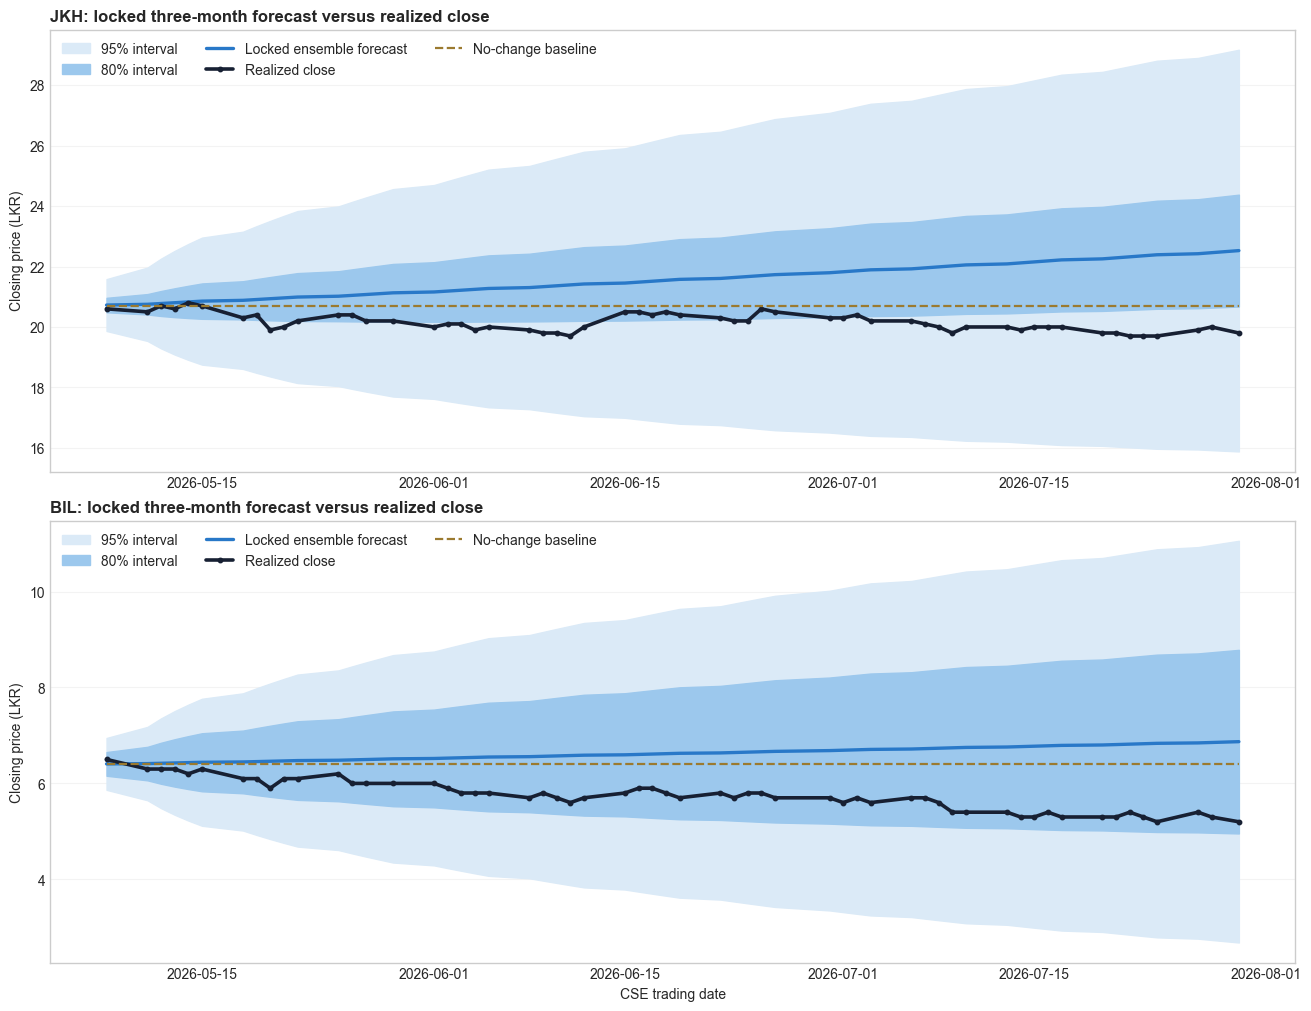

In [4]:
palette = {
    "actual": "#172033",
    "forecast": "#2878c8",
    "interval_80": "#9cc8ed",
    "interval_95": "#dbeaf7",
    "baseline": "#9b7a2f",
}

fig, axes = plt.subplots(2, 1, figsize=(13, 10), constrained_layout=True)

for axis, (stock, matched) in zip(axes, evaluation_frames.items()):
    axis.fill_between(
        matched["date"], matched["lower_95"], matched["upper_95"],
        color=palette["interval_95"], label="95% interval"
    )
    axis.fill_between(
        matched["date"], matched["lower_80"], matched["upper_80"],
        color=palette["interval_80"], label="80% interval"
    )
    axis.plot(
        matched["date"], matched["predicted_close"],
        color=palette["forecast"], linewidth=2.4, label="Locked ensemble forecast"
    )
    axis.plot(
        matched["date"], matched["close"],
        color=palette["actual"], linewidth=2.6, marker="o", markersize=3.2,
        label="Realized close"
    )
    axis.plot(
        matched["date"], matched["naive_random_walk_close"],
        color=palette["baseline"], linewidth=1.6, linestyle="--", label="No-change baseline"
    )
    axis.set_title(f"{stock}: locked three-month forecast versus realized close", loc="left", weight="bold")
    axis.set_ylabel("Closing price (LKR)")
    axis.grid(axis="y", alpha=0.22)
    axis.grid(axis="x", visible=False)
    axis.legend(ncol=3, frameon=False, loc="upper left")

axes[-1].set_xlabel("CSE trading date")
figure_path = OUTPUT_DIR / "forecast_vs_actual.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

### 5. Evaluate interval coverage and endpoint error

Coverage answers whether observations stayed inside an interval; it does not show whether the centre
of that interval was accurate. Very wide intervals can achieve high coverage while providing weak
decision precision, so interval width is reported alongside coverage.

In [5]:
interval_rows = []
endpoint_rows = []

for stock, matched in evaluation_frames.items():
    for level in [80, 95]:
        lower = matched[f"lower_{level}"]
        upper = matched[f"upper_{level}"]
        interval_rows.append(
            {
                "stock": stock,
                "interval": f"{level}%",
                "coverage_pct": ((matched["close"] >= lower) & (matched["close"] <= upper)).mean() * 100,
                "mean_width_lkr": (upper - lower).mean(),
            }
        )

    final = matched.iloc[-1]
    first = matched.iloc[0]
    endpoint_rows.append(
        {
            "stock": stock,
            "evaluation_start": first["date"].date(),
            "evaluation_end": final["date"].date(),
            "first_actual_lkr": first["close"],
            "final_actual_lkr": final["close"],
            "final_forecast_lkr": final["predicted_close"],
            "endpoint_error_lkr": final["predicted_close"] - final["close"],
            "endpoint_error_pct": (final["predicted_close"] - final["close"]) / final["close"] * 100,
            "actual_period_change_pct": (final["close"] / first["close"] - 1) * 100,
        }
    )

interval_df = pd.DataFrame(interval_rows)
endpoint_df = pd.DataFrame(endpoint_rows)
interval_df.to_csv(OUTPUT_DIR / "forecast_interval_validation.csv", index=False)
endpoint_df.to_csv(OUTPUT_DIR / "forecast_endpoint_validation.csv", index=False)

display(interval_df.style.format({"coverage_pct": "{:.2f}%", "mean_width_lkr": "{:.4f}"}))
display(
    endpoint_df.style.format(
        {
            "first_actual_lkr": "{:.2f}",
            "final_actual_lkr": "{:.2f}",
            "final_forecast_lkr": "{:.2f}",
            "endpoint_error_lkr": "{:+.2f}",
            "endpoint_error_pct": "{:+.2f}%",
            "actual_period_change_pct": "{:+.2f}%",
        }
    )
)

,stock,interval,coverage_pct,mean_width_lkr
0,JKH,80%,38.60%,2.4809
1,JKH,95%,100.00%,8.9086
2,BIL,80%,100.00%,2.5653
3,BIL,95%,100.00%,5.6125


,stock,evaluation_start,evaluation_end,first_actual_lkr,final_actual_lkr,final_forecast_lkr,endpoint_error_lkr,endpoint_error_pct,actual_period_change_pct
0,JKH,2026-05-08,2026-07-30,20.60,19.80,22.53,+2.73,+13.78%,-3.88%
1,BIL,2026-05-08,2026-07-30,6.50,5.20,6.87,+1.67,+32.13%,-20.00%


### 6. Compare the ensemble with its baselines

Lower MAE is better. The comparison is essential because a complex forecast is not useful merely
because it produces a plausible-looking curve; it should improve on a transparent baseline.

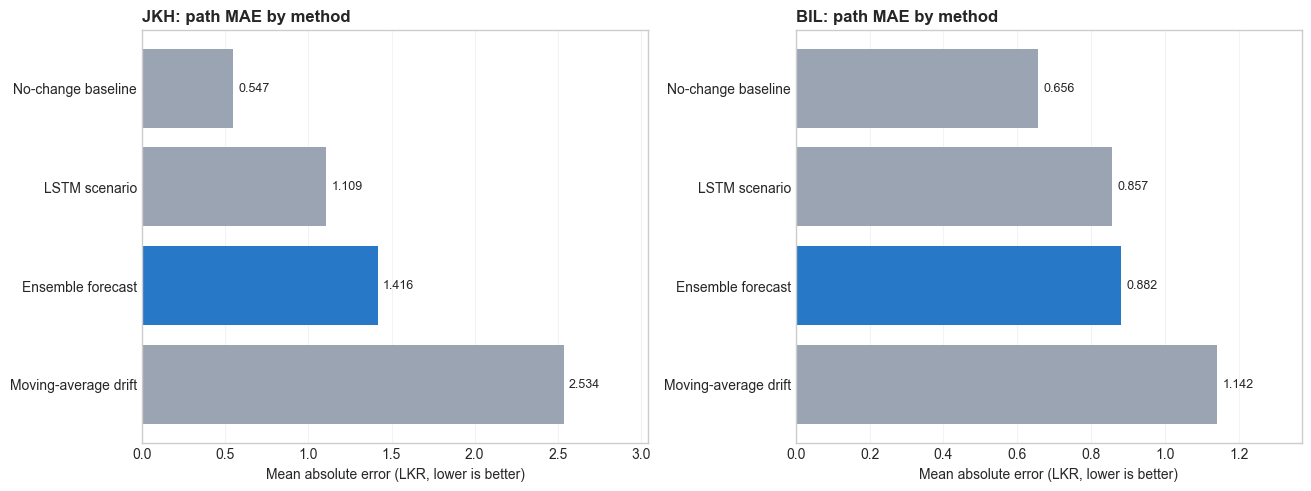

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

for axis, stock in zip(axes, STOCKS):
    stock_metrics = metrics_df[metrics_df["stock"] == stock].sort_values("mae_lkr")
    colors = [palette["forecast"] if model == "Ensemble forecast" else "#9aa4b2" for model in stock_metrics["model"]]
    bars = axis.barh(stock_metrics["model"], stock_metrics["mae_lkr"], color=colors)
    axis.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
    axis.set_title(f"{stock}: path MAE by method", loc="left", weight="bold")
    axis.set_xlabel("Mean absolute error (LKR, lower is better)")
    axis.invert_yaxis()
    axis.grid(axis="x", alpha=0.22)
    axis.grid(axis="y", visible=False)
    axis.set_xlim(0, stock_metrics["mae_lkr"].max() * 1.2)

comparison_path = OUTPUT_DIR / "forecast_model_comparison.png"
fig.savefig(comparison_path, dpi=180, bbox_inches="tight")
plt.show()

### 7. Quantify forecast deviation without mislabelling it

The original component's anomaly score is designed for deviation from a model's expected price and
is liquidity-aware:

`absolute deviation / (volume in millions + epsilon)`

Below, the same formula is applied to the long-horizon forecast only as a **post-forecast deviation
diagnostic**. It is not interchangeable with the one-step anomaly detector and is not evaluated against
ground-truth event labels. A high value means the realized close was far from the saved scenario on a
relatively low-volume day; it does not identify the external cause.

In [7]:
deviation_rows = []

for stock, matched in evaluation_frames.items():
    diagnostic = matched.copy()
    diagnostic["absolute_forecast_deviation_lkr"] = (diagnostic["close"] - diagnostic["predicted_close"]).abs()
    diagnostic["forecast_deviation_pct"] = diagnostic["absolute_forecast_deviation_lkr"] / diagnostic["close"] * 100
    diagnostic["post_forecast_liquidity_score"] = diagnostic["absolute_forecast_deviation_lkr"] / (
        diagnostic["volume"] / 1_000_000 + 1e-6
    )
    diagnostic["stock"] = stock
    diagnostic.to_csv(OUTPUT_DIR / f"{stock}_forecast_deviation_diagnostic.csv", index=False)

    final = diagnostic.iloc[-1]
    peak = diagnostic.loc[diagnostic["post_forecast_liquidity_score"].idxmax()]
    deviation_rows.append(
        {
            "stock": stock,
            "endpoint_deviation_lkr": final["absolute_forecast_deviation_lkr"],
            "endpoint_deviation_pct": final["forecast_deviation_pct"],
            "endpoint_liquidity_score": final["post_forecast_liquidity_score"],
            "peak_score_date": peak["date"].date(),
            "peak_liquidity_score": peak["post_forecast_liquidity_score"],
        }
    )

deviation_summary_df = pd.DataFrame(deviation_rows)
deviation_summary_df.to_csv(OUTPUT_DIR / "forecast_deviation_summary.csv", index=False)
display(
    deviation_summary_df.style.format(
        {
            "endpoint_deviation_lkr": "{:.4f}",
            "endpoint_deviation_pct": "{:.2f}%",
            "endpoint_liquidity_score": "{:.4f}",
            "peak_liquidity_score": "{:.4f}",
        }
    )
)

,stock,endpoint_deviation_lkr,endpoint_deviation_pct,endpoint_liquidity_score,peak_score_date,peak_liquidity_score
0,JKH,2.7275,13.78%,1.4989,2026-07-21,5.0792
1,BIL,1.6708,32.13%,0.5744,2026-07-27,6.4888


## Takeaways

1. **The saved upward point forecasts were not confirmed.** JKH declined by 3.88% across matched
   endpoints while the ensemble expected an 8.83% increase from the May 7 anchor. BIL declined by
   20.00% while the ensemble expected a 7.36% increase.
2. **The model did not beat the no-change baseline.** JKH ensemble MAE was LKR 1.416 versus
   LKR 0.547 for the baseline. BIL ensemble MAE was LKR 0.882 versus LKR 0.656.
3. **Uncertainty was broad.** The 95% bands covered all observations, but their large widths mean
   this should not be presented as strong point-forecast reliability.
4. **The result is a useful model failure analysis.** It suggests that long-horizon drift and ensemble
   weighting need recalibration, particularly under regime changes or external shocks.
5. **Anomaly and causality remain separate.** Price deviation can flag unusual behaviour, but company
   reports, relevant news and macroeconomic evidence are needed before explaining why it happened.

### Required research follow-up

- Add rolling-origin, horizon-specific backtests for 4 trading days, 1 month, 3 months and 6 months.
- Reweight or reject ensemble members using validation-only performance.
- Compare against no-change and drift baselines at every horizon.
- Calibrate intervals separately by forecast horizon and report interval width with coverage.
- Use official CSE/MyCSE data as a final reconciliation source before thesis publication.
- Do not claim validation for a third stock unless its timestamped pre-period forecast is recovered.

### Scope statement

This notebook validates two stocks because only JKH and BIL have recoverable, timestamped forecasts
and matching model artifacts. It would be scientifically incorrect to generate a third historical
forecast after observing the outcome and then call it out-of-sample validation.

**This research system provides decision-support information, not buying or selling advice.**